                                          МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РФ
                                     фЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ ОБРАЗОВАТЕЛЬНОЕ
                                                УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ
                                   РОСТОВСКИЙ ГОСУДАРСТВЕННЫЙ ЭКОНОМИЧЕСКИЙ УНИВЕРСИТЕТ (РИНХ)




                                                      Методы машинного обучения
                                                        Лабораторная работа №4

                                                                           
                                                                            
                                                                             
                                                                              
                                                                              Работу выполнил студент        
                                                                                      Группы ПИ-811
                                                                                        Бойко В.А.


https://archive.ics.uci.edu/dataset/186/wine+quality

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, average_precision_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SequentialFeatureSelector

plt.rc('font', size=16)          # размеры текста по умолчанию
plt.rc('axes', titlesize=20)     # размер шрифта заголовка осей
plt.rc('axes', labelsize=18)     # размер шрифта названия осей
plt.rc('xtick', labelsize=18)    # размер шрифта меток по оси x
plt.rc('ytick', labelsize=18)    # размер шрифта меток по оси y
plt.rc('legend', fontsize=16)    # размер шрифта легенды
plt.rc('figure', titlesize=20)   # размер шрифта заголовка всего графика

In [81]:
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

red_wine['wine_type'] = 'red'
white_wine['wine_type'] = 'white'

In [82]:
wine_data = pd.concat([red_wine, white_wine], ignore_index=True)

In [83]:
wine_data.shape

(6497, 13)

In [84]:
wine_data['is_high_quality'] = (wine_data['quality'] >= 6).astype(int)
quality_counts = wine_data['is_high_quality'].value_counts()

In [86]:
X = wine_data.drop(['quality', 'is_high_quality'], axis=1)
y = wine_data['is_high_quality']

X = pd.get_dummies(X, columns=['wine_type'], drop_first=True)
print(f"Итоговое количество признаков: {X.shape[1]}")

Итоговое количество признаков: 12


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((4547, 12), (1950, 12))

In [ ]:
from sklearn.metrics import f1_score, average_precision_score, accuracy_score, classification_report

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"МОДЕЛЬ: {model_name}")
    
    try:
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = None
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_proba is not None:
            pr_auc = average_precision_score(y_test, y_proba)
        else:
            pr_auc = 0.0
        
        print(f"Accuracy: {accuracy:.3f}")
        print(f"F1-score: {f1:.3f}")
        print(f"PR AUC: {pr_auc:.3f}")
        
        return {
            'model': model,
            'predictions': y_pred,
            'probabilities': y_proba,
            'metrics': {
                'Accuracy': accuracy,
                'F1-score': f1,
                'PR AUC': pr_auc
            }
        }
        
    except Exception as e:
        print(f"Ошибка: {e}")
        return None


Обучение модели

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

models_to_test = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("XGBoost", XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')),
    ("AdaBoost", AdaBoostClassifier(n_estimators=100, random_state=42)),
]

results = {}

In [90]:
for name, model in models_to_test:
    result = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    if result is not None:
        results[name] = result

МОДЕЛЬ: Logistic Regression
Accuracy: 0.738
F1-score: 0.804
PR AUC: 0.868
МОДЕЛЬ: Random Forest
Accuracy: 0.828
F1-score: 0.868
PR AUC: 0.926
МОДЕЛЬ: XGBoost
Accuracy: 0.814
F1-score: 0.857
PR AUC: 0.914
МОДЕЛЬ: AdaBoost
Accuracy: 0.753
F1-score: 0.812
PR AUC: 0.876


Сравнение результатов


Модели отсортированы по F1-score:
                     Accuracy  F1-score    PR AUC
Random Forest        0.827692  0.867508  0.925681
XGBoost              0.813846  0.856805  0.914051
AdaBoost             0.752821  0.812451  0.876224
Logistic Regression  0.737949  0.803989  0.867638


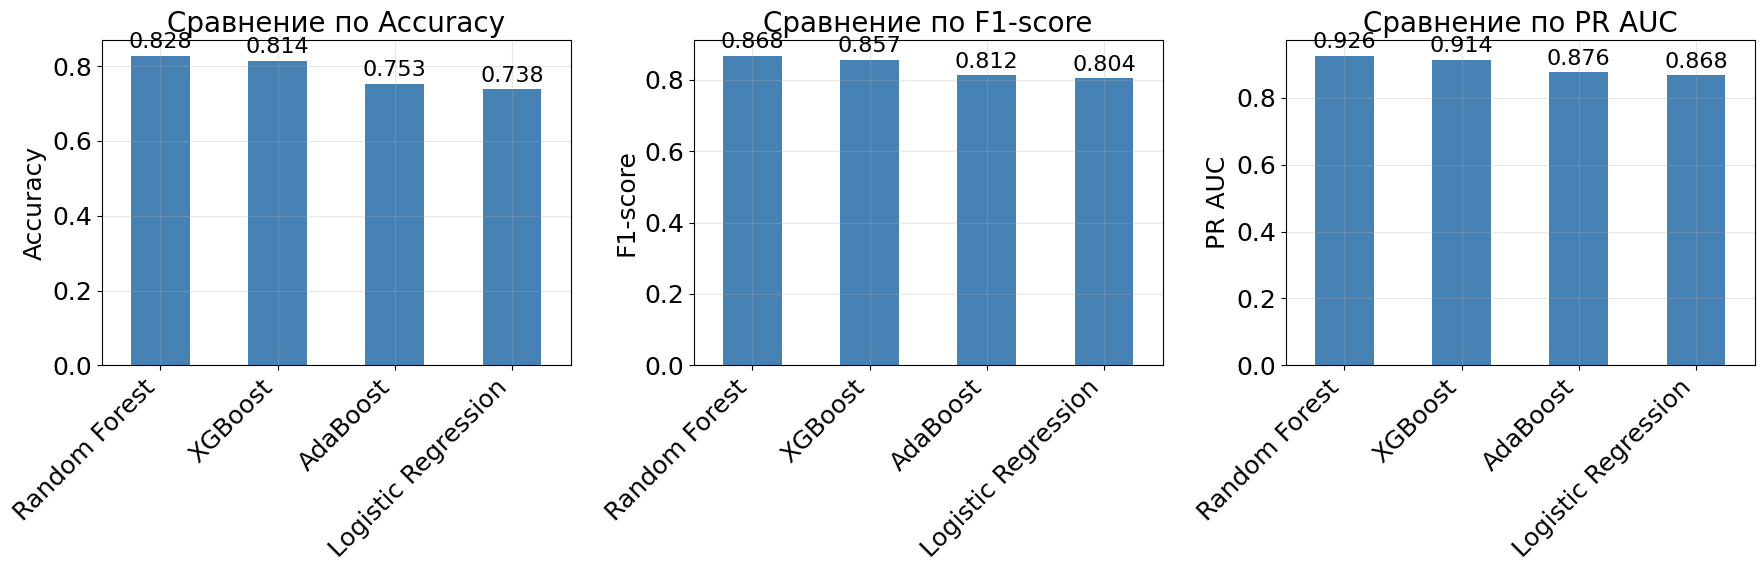


ЛУЧШАЯ МОДЕЛЬ: Random Forest
F1-score: 0.868


In [91]:
if results:
    metrics_data = []
    model_names = []
    
    for name, result in results.items():
        model_names.append(name)
        metrics_data.append(result['metrics'])
    
    results_df = pd.DataFrame(metrics_data, index=model_names)
    
    results_df_sorted = results_df.sort_values('F1-score', ascending=False)
    
    print("\nМодели отсортированы по F1-score:")
    print(results_df_sorted)
    
    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    metrics_to_plot = ['Accuracy', 'F1-score', 'PR AUC']
    
    for i, metric in enumerate(metrics_to_plot):
        if metric in results_df_sorted.columns:
            ax = axes[i]
            results_df_sorted[metric].plot(kind='bar', ax=ax, color='steelblue')
            ax.set_title(f'Сравнение по {metric}')
            ax.set_ylabel(metric)
            ax.set_xticklabels(results_df_sorted.index, rotation=45, ha='right')
            ax.grid(True, alpha=0.3)
            
            for j, v in enumerate(results_df_sorted[metric]):
                ax.text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    best_model_name = results_df_sorted.index[0]
    print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"F1-score: {results_df_sorted.loc[best_model_name, 'F1-score']:.3f}")
    
else:
    print("Ни одна модель не была успешно обучена")

Анализ важности признаков

Анализ важности признаков для модели: Random Forest
Топ-10 самых важных признаков:
                 feature  importance
10               alcohol    0.155648
1       volatile acidity    0.115696
7                density    0.103493
6   total sulfur dioxide    0.085312
4              chlorides    0.084438
2            citric acid    0.080783
9              sulphates    0.078452
5    free sulfur dioxide    0.077953
3         residual sugar    0.077659
8                     pH    0.071823


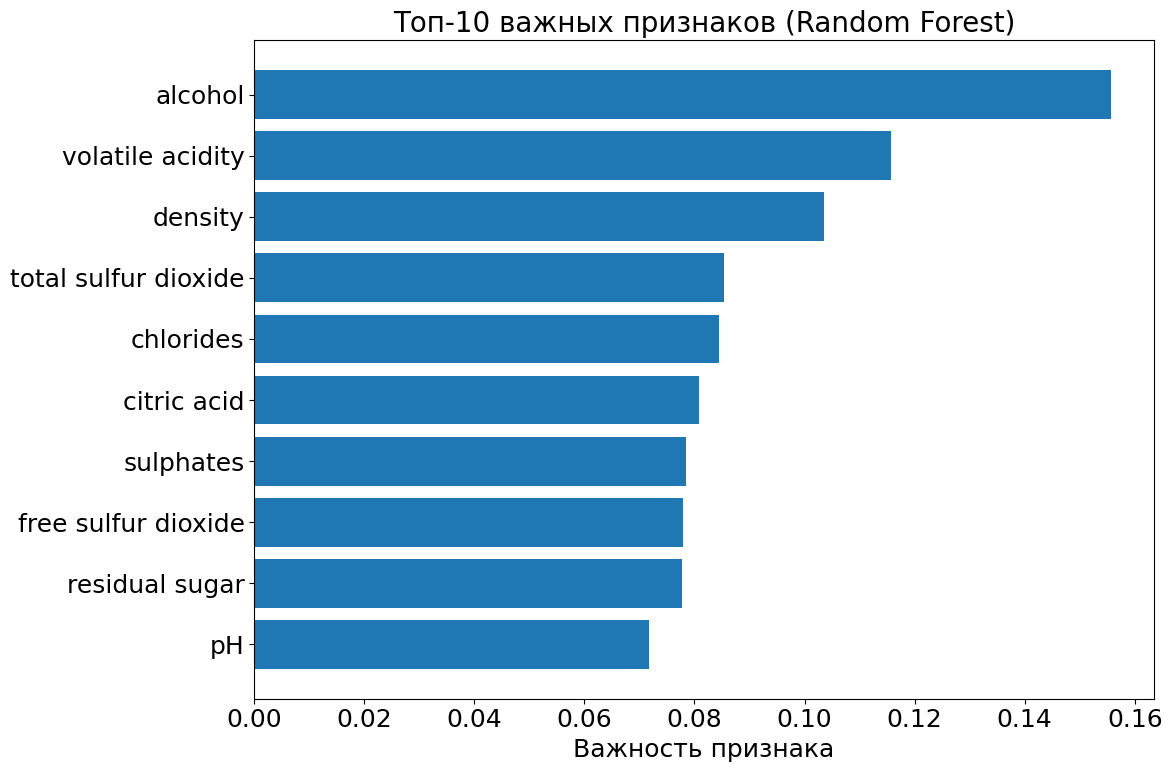

Важность признака 'тип вина':
  wine_type_white: 0.0035


<Figure size 800x600 with 0 Axes>

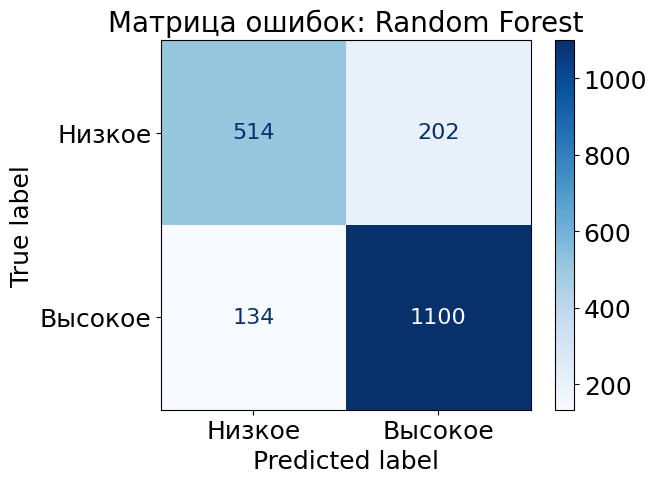

Отчет о классификации для Random Forest:
                  precision    recall  f1-score   support

 Низкое качество       0.79      0.72      0.75       716
Высокое качество       0.84      0.89      0.87      1234

        accuracy                           0.83      1950
       macro avg       0.82      0.80      0.81      1950
    weighted avg       0.83      0.83      0.83      1950



In [93]:
if results:
    if 'Random Forest' in results:
        model_for_fi = results['Random Forest']['model']
        model_name = "Random Forest"
    else:
        model_name = list(results.keys())[0]
        model_for_fi = results[model_name]['model']
    
    print(f"Анализ важности признаков для модели: {model_name}")
    
    if hasattr(model_for_fi, 'feature_importances_'):
        feature_importances = pd.DataFrame({
            'feature': X.columns,
            'importance': model_for_fi.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("Топ-10 самых важных признаков:")
        print(feature_importances.head(10))
        
        # Визуализация
        plt.figure(figsize=(12, 8))
        plt.barh(feature_importances['feature'][:10][::-1], 
                feature_importances['importance'][:10][::-1])
        plt.xlabel('Важность признака')
        plt.title(f'Топ-10 важных признаков ({model_name})')
        plt.tight_layout()
        plt.show()
        
        # Проверяем важность типа вина
        wine_type_features = [col for col in X.columns if 'wine_type' in col]
        if wine_type_features:
            print(f"Важность признака 'тип вина':")
            for feature in wine_type_features:
                if feature in feature_importances['feature'].values:
                    importance = feature_importances.loc[
                        feature_importances['feature'] == feature, 'importance'
                    ].values[0]
                    print(f"  {feature}: {importance:.4f}")
    else:
        print(f"Модель {model_name} не поддерживает feature_importances_")
        
    # Матрица ошибок для лучшей модели
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    
    best_model_result = results[best_model_name]
    cm = confusion_matrix(y_test, best_model_result['predictions'])
    
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=['Низкое', 'Высокое'])
    disp.plot(cmap='Blues')
    plt.title(f'Матрица ошибок: {best_model_name}')
    plt.show()
    
    # Отчет о классификации
    print(f"Отчет о классификации для {best_model_name}:")
    print(classification_report(y_test, best_model_result['predictions'], 
                               target_names=['Низкое качество', 'Высокое качество']))

In [96]:
def model_train_test(X_train, y_train, X_test, y_test, model):
    """Обучение и тестирование модели с возвратом метрик"""
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_proba is not None:
        pr_auc = average_precision_score(y_test, y_proba)
    else:
        pr_auc = 0.0
    
    metrics = {
        'Accuracy': accuracy,
        'F1-score': f1,
        'PR AUC': pr_auc
    }
    
    return model, y_pred, y_proba, metrics

In [97]:
def get_model_name_fi(model, fi_type="builded", X_train=None):
    if fi_type == "builded":
        if hasattr(model, 'feature_importances_'):
            # Для RandomForest, XGBoost
            fi_values = model.feature_importances_
        elif hasattr(model, 'coef_'):
            # Для LogisticRegression
            fi_values = np.abs(model.coef_[0])
        else:
            raise ValueError(f"Модель {type(model).__name__} не поддерживает feature_importances_ или coef_")
        return "Встроенная важность признаков", fi_values
    
    elif fi_type == "shap":
        try:
            import shap
            # Создаем explainer
            if 'randomforest' in str(type(model)).lower() or 'xgb' in str(type(model)).lower():
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X_train)
                if isinstance(shap_values, list):
                    shap_values = shap_values[1]  # для бинарной классификации
                return "SHAP важность признаков", shap_values
            else:
                raise ValueError(f"Модель {type(model).__name__} не совместима с SHAP TreeExplainer")
        except ImportError:
            raise ImportError("SHAP не установлен")
    
    else:
        raise ValueError(f"Неизвестный тип fi_type: {fi_type}")

In [98]:
def train_test_n_most_worst_important(n, sorted_idx, columns, model, X_train, y_train, X_test, y_test):
    top_n_features = columns[sorted_idx[:-n-1:-1]].tolist()
    print(
        "{} наиболее важных признаков:\n{}".format(
            n, top_n_features
        )
    )
    model_top_n, pred_top_n, proba_top_n, all_metrics_top_n = model_train_test(
        X_train[top_n_features], y_train,
        X_test[top_n_features], y_test,
        model,
    )
    bottom_n_features = columns[sorted_idx[:n]].tolist()
    print(
        "{} наименее важных признаков:\n{}".format(
            n, bottom_n_features
        )
    )
    model_bottom_n, pred_bottom_n, proba_bottom_n, all_metrics_bottom_n = model_train_test(
        X_train[bottom_n_features], y_train,
        X_test[bottom_n_features], y_test,
        model,
    )
    return (
        (
           top_n_features,
           model_top_n,
           pred_top_n,
           proba_top_n,
           all_metrics_top_n
       ), (
            bottom_n_features,
            model_bottom_n,
            pred_bottom_n,
            proba_bottom_n,
            all_metrics_bottom_n
        )
    )


In [99]:

CONFIG = {
    "n": 5,
    "columns": X_train.columns,
    "model": None,  # Будет установлено ниже
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
}


In [100]:

if results:
    if 'F1-score' in results_df_sorted.columns:
        best_model_name = results_df_sorted.index[0]
        best_model = results[best_model_name]['model']
        print(f"Используем лучшую модель: {best_model_name}")
        
        # Проверяем, совместима ли модель с XGBoost для анализа
        if 'XGBoost' in str(type(best_model)):
            model_for_analysis = best_model
        else:
            # Если лучшая модель не XGBoost, используем Random Forest или XGBoost
            if 'Random Forest' in results:
                model_for_analysis = results['Random Forest']['model']
                print(f"Лучшая модель не XGBoost, используем Random Forest для анализа")
            else:
                model_for_analysis = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
                print(f"Создаем новый XGBoost классификатор для анализа")
    else:
        model_for_analysis = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
else:
    model_for_analysis = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')


Используем лучшую модель: Random Forest
Лучшая модель не XGBoost, используем Random Forest для анализа


In [101]:

CONFIG["model"] = model_for_analysis


In [102]:
model_for_analysis.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [103]:
try:
    fi_name, fi_builtin = get_model_name_fi(model_for_analysis, fi_type="builded")
    sorted_idx_builtin = np.argsort(fi_builtin)
    
    print("\n" + "="*80)
    print(f"АНАЛИЗ НА ОСНОВЕ ВСТРОЕННОЙ ВАЖНОСТИ ПРИЗНАКОВ ({fi_name})")
    print("="*80)
    
    best_builtin, worst_builtin = train_test_n_most_worst_important(
        sorted_idx=sorted_idx_builtin,
        **CONFIG
    )
except Exception as e:
    print(f"Ошибка при получении встроенной важности признаков: {e}")
    best_builtin, worst_builtin = (None, None), (None, None)



АНАЛИЗ НА ОСНОВЕ ВСТРОЕННОЙ ВАЖНОСТИ ПРИЗНАКОВ (Встроенная важность признаков)
5 наиболее важных признаков:
['alcohol', 'volatile acidity', 'density', 'total sulfur dioxide', 'chlorides']
5 наименее важных признаков:
['wine_type_white', 'fixed acidity', 'pH', 'residual sugar', 'free sulfur dioxide']


In [104]:
try:
    import shap
    
    print("АНАЛИЗ НА ОСНОВЕ SHAP ВАЖНОСТИ ПРИЗНАКОВ")
    model_type = str(type(model_for_analysis)).lower()
    if 'randomforest' in model_type or 'xgb' in model_type:
        _, fi_shap_values = get_model_name_fi(model_for_analysis, fi_type="shap", X_train=X_train)
        
        fi_shap_importance = np.abs(fi_shap_values).mean(axis=0)
        sorted_idx_shap = np.argsort(fi_shap_importance)
        
        best_shap, worst_shap = train_test_n_most_worst_important(
            sorted_idx=sorted_idx_shap,
            **CONFIG
        )
    else:
        print(f"Модель {type(model_for_analysis).__name__} не совместима с SHAP TreeExplainer")
        best_shap, worst_shap = (None, None), (None, None)
        
except ImportError:
    print("SHAP не установлен. Пропускаем SHAP анализ.")
    best_shap, worst_shap = (None, None), (None, None)
except Exception as e:
    print(f"Ошибка при SHAP анализе: {e}")
    best_shap, worst_shap = (None, None), (None, None)



АНАЛИЗ НА ОСНОВЕ SHAP ВАЖНОСТИ ПРИЗНАКОВ
Ошибка при SHAP анализе: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.


АНАЛИЗ НА ОСНОВЕ ПОСЛЕДОВАТЕЛЬНОГО ОТБОРА ПРИЗНАКОВ

In [105]:
fbs_model = XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss')
fbs = SequentialFeatureSelector(fbs_model, n_features_to_select=5, cv=3, n_jobs=-1)
fbs.fit(X_train, y_train)

top_5_features_fbs = X_train.columns[fbs.support_]
top_5_features_fbs

Index(['fixed acidity', 'volatile acidity', 'residual sugar',
       'total sulfur dioxide', 'alcohol'],
      dtype='object')

In [106]:
best_fbs_result = model_train_test(
    X_train[top_5_features_fbs], y_train,
    X_test[top_5_features_fbs], y_test,
    XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
)

In [ ]:
bottom_features_fbs = X_train.columns[~fbs.support_]

len(bottom_features_fbs), bottom_features_fbs.tolist()

(7,
 ['citric acid',
  'chlorides',
  'free sulfur dioxide',
  'density',
  'pH',
  'sulphates',
  'wine_type_white'])

In [ ]:
if len(bottom_features_fbs) > 0:
    n_bottom = min(5, len(bottom_features_fbs))
    bottom_n_features_fbs = bottom_features_fbs[:n_bottom].tolist()
    
    print(f"\n{n_bottom} наименее важных признаков по SequentialFeatureSelector:\n", bottom_n_features_fbs)
    
    worst_fbs_result = model_train_test(
        X_train[bottom_n_features_fbs], y_train,
        X_test[bottom_n_features_fbs], y_test,
        XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    )
else:
    print("Все признаки вошли в топ-5, невозможно определить наименее важные")
    worst_fbs_result = (None, None, None, {'F1-score': 0, 'PR AUC': 0})


СРАВНЕНИЕ РЕЗУЛЬТАТОВ РАЗНЫХ МЕТОДОВ ОТБОРА ПРИЗНАКОВ


Сравнение метрик для разных методов отбора признаков:
                               Accuracy  F1-score    PR AUC
Built-in FI - Top 5            0.796923  0.843354  0.909729
Seq Feature Selector - Top 5   0.781026  0.830757  0.888108
Seq Feature Selector - Bottom  0.751282  0.812234  0.870683
Built-in FI - Bottom 5         0.734359  0.800000  0.868170


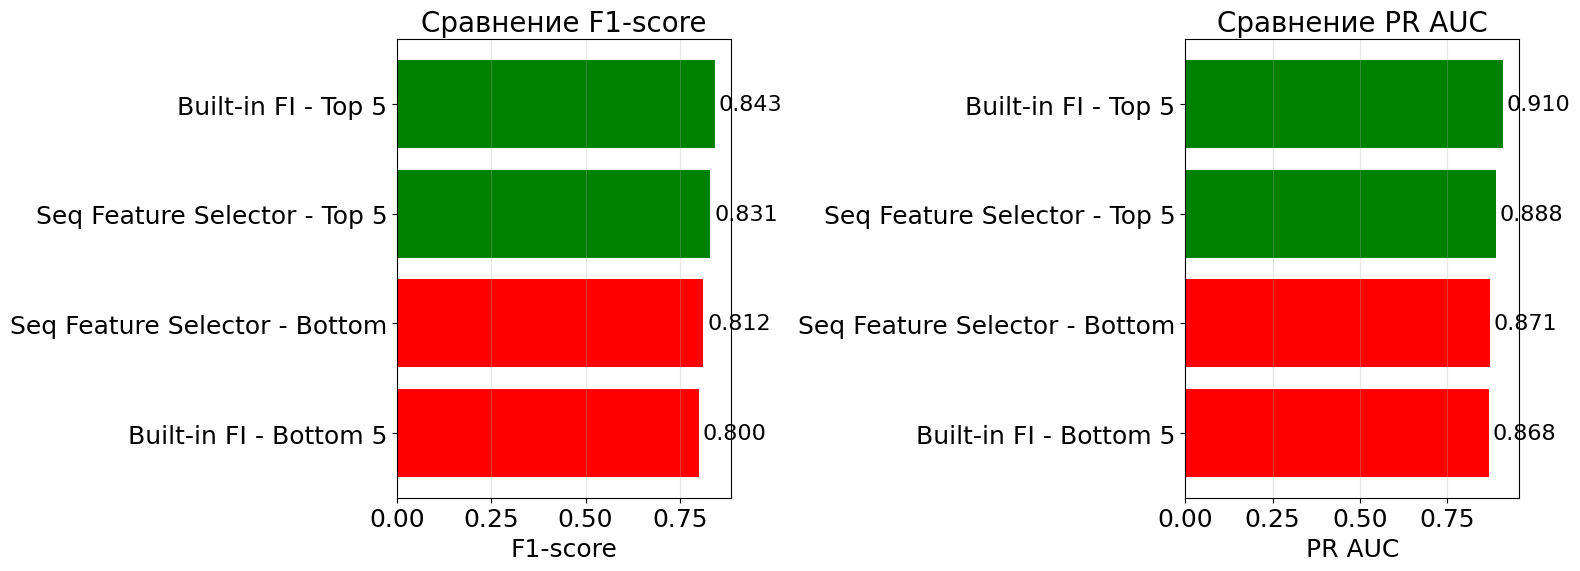


Таблица совпадений топ-5 признаков:
                     Built-in FI Seq Feature Selector
Built-in FI                    5               3 из 5
Seq Feature Selector      3 из 5                    5


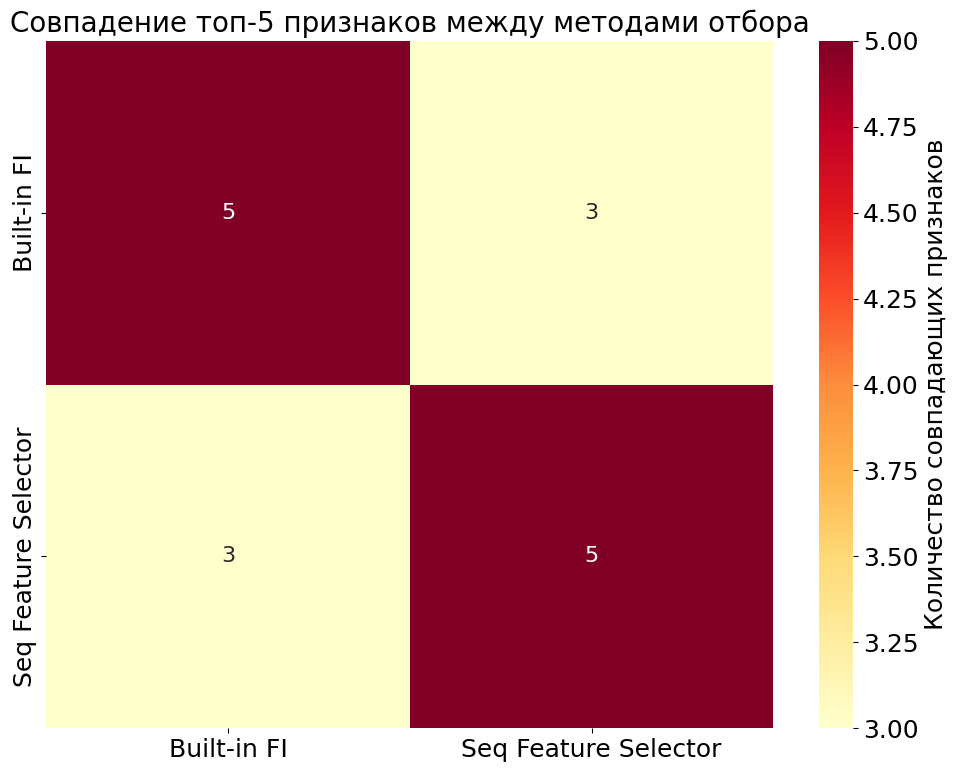


Всего уникальных признаков в топ-5 разных методов: 7

Частота появления признаков в топ-5 разных методов:
  alcohol: 2/2 методов
  total sulfur dioxide: 2/2 методов
  volatile acidity: 2/2 методов
  fixed acidity: 1/2 методов
  density: 1/2 методов
  chlorides: 1/2 методов
  residual sugar: 1/2 методов

Признаки, которые есть во всех методах (3):
  • alcohol
  • total sulfur dioxide
  • volatile acidity


In [110]:
comparison_data = []
comparison_index = []

if best_builtin[0] is not None and best_builtin[4] is not None:
    comparison_data.append(best_builtin[4])
    comparison_index.append("Built-in FI - Top 5")
    
if worst_builtin[0] is not None and worst_builtin[4] is not None:
    comparison_data.append(worst_builtin[4])
    comparison_index.append("Built-in FI - Bottom 5")

if best_shap[0] is not None and best_shap[4] is not None:
    comparison_data.append(best_shap[4])
    comparison_index.append("SHAP - Top 5")
    
if worst_shap[0] is not None and worst_shap[4] is not None:
    comparison_data.append(worst_shap[4])
    comparison_index.append("SHAP - Bottom 5")

if best_fbs_result and best_fbs_result[3]:
    comparison_data.append(best_fbs_result[3])
    comparison_index.append("Seq Feature Selector - Top 5")
else:
    comparison_data.append({'F1-score': 0, 'PR AUC': 0, 'Accuracy': 0})
    comparison_index.append("Seq Feature Selector - Top 5")

if worst_fbs_result and worst_fbs_result[3]:
    comparison_data.append(worst_fbs_result[3])
    comparison_index.append("Seq Feature Selector - Bottom")
else:
    comparison_data.append({'F1-score': 0, 'PR AUC': 0, 'Accuracy': 0})
    comparison_index.append("Seq Feature Selector - Bottom")

if comparison_data:
    metrics_comparison_df = pd.DataFrame(
        comparison_data,
        index=comparison_index
    )
    
    print("\nСравнение метрик для разных методов отбора признаков:")
    print(metrics_comparison_df.sort_values(by=["F1-score", "PR AUC"], ascending=False))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].barh(range(len(metrics_comparison_df)), 
                metrics_comparison_df.sort_values('F1-score')['F1-score'],
                color=['red' if 'Bottom' in idx else 'green' for idx in metrics_comparison_df.sort_values('F1-score').index])
    axes[0].set_yticks(range(len(metrics_comparison_df)))
    axes[0].set_yticklabels(metrics_comparison_df.sort_values('F1-score').index)
    axes[0].set_xlabel('F1-score')
    axes[0].set_title('Сравнение F1-score')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    for i, v in enumerate(metrics_comparison_df.sort_values('F1-score')['F1-score']):
        axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')
    
    axes[1].barh(range(len(metrics_comparison_df)), 
                metrics_comparison_df.sort_values('PR AUC')['PR AUC'],
                color=['red' if 'Bottom' in idx else 'green' for idx in metrics_comparison_df.sort_values('PR AUC').index])
    axes[1].set_yticks(range(len(metrics_comparison_df)))
    axes[1].set_yticklabels(metrics_comparison_df.sort_values('PR AUC').index)
    axes[1].set_xlabel('PR AUC')
    axes[1].set_title('Сравнение PR AUC')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    for i, v in enumerate(metrics_comparison_df.sort_values('PR AUC')['PR AUC']):
        axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    top_features_sets = {}
    
    if best_builtin[0]:
        top_features_sets["Built-in FI"] = set(best_builtin[0])
    
    if best_shap[0]:
        top_features_sets["SHAP"] = set(best_shap[0])
    
    top_features_sets["Seq Feature Selector"] = set(top_5_features_fbs)
    
    if len(top_features_sets) >= 2:
        
        methods = list(top_features_sets.keys())
        overlap_matrix = pd.DataFrame(index=methods, columns=methods)
        
        for i, method1 in enumerate(methods):
            for j, method2 in enumerate(methods):
                if i == j:
                    overlap_matrix.loc[method1, method2] = len(top_features_sets[method1])
                else:
                    intersection = top_features_sets[method1].intersection(top_features_sets[method2])
                    overlap_matrix.loc[method1, method2] = f"{len(intersection)} из {len(top_features_sets[method1])}"
        
        print("\nТаблица совпадений топ-5 признаков:")
        print(overlap_matrix)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Создаем heatmap
        import seaborn as sns
        
        numeric_matrix = pd.DataFrame(index=methods, columns=methods)
        for i, method1 in enumerate(methods):
            for j, method2 in enumerate(methods):
                if i == j:
                    numeric_matrix.loc[method1, method2] = len(top_features_sets[method1])
                else:
                    intersection = top_features_sets[method1].intersection(top_features_sets[method2])
                    numeric_matrix.loc[method1, method2] = len(intersection)
        
        sns.heatmap(numeric_matrix.astype(float), annot=True, fmt='.0f', cmap='YlOrRd',
                   cbar_kws={'label': 'Количество совпадающих признаков'})
        plt.title('Совпадение топ-5 признаков между методами отбора')
        plt.tight_layout()
        plt.show()
        
        all_top_features = set()
        for features_set in top_features_sets.values():
            all_top_features.update(features_set)
        
        print(f"\nВсего уникальных признаков в топ-5 разных методов: {len(all_top_features)}")
        
        feature_counts = {}
        for feature in all_top_features:
            count = sum(1 for features_set in top_features_sets.values() if feature in features_set)
            feature_counts[feature] = count
        
        sorted_features = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)
        
        print("\nЧастота появления признаков в топ-5 разных методов:")
        for feature, count in sorted_features:
            print(f"  {feature}: {count}/{len(methods)} методов")
            
        common_features = set.intersection(*top_features_sets.values())
        if common_features:
            print(f"\nПризнаки, которые есть во всех методах ({len(common_features)}):")
            for feature in common_features:
                print(f"  • {feature}")
        else:
            print("\nНет признаков, которые есть во всех методах")
            
        wine_type_features = [f for f in all_top_features if 'wine_type' in f]
        if wine_type_features:
            print(f"\nПризнак типа вина в топ-признаках:")
            for feature in wine_type_features:
                methods_with_feature = [method for method, features_set in top_features_sets.items() 
                                      if feature in features_set]
                print(f"  {feature}: присутствует в {len(methods_with_feature)}/{len(methods)} методах")
                print(f"    Методы: {', '.join(methods_with_feature)}")

if 'shap' in locals() and best_shap[0] is not None:
    try:
        print("ДОПОЛНИТЕЛЬНЫЙ SHAP АНАЛИЗ ДЛЯ ИНТЕРПРЕТАЦИИ")
        
        explainer = shap.TreeExplainer(model_for_analysis)
        shap_values = explainer.shap_values(X_train)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # для бинарной классификации
        
        shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
        plt.title(f'Средняя абсолютная SHAP важность признаков')
        plt.tight_layout()
        plt.show()
        
        shap.summary_plot(shap_values, X_train, show=False)
        plt.title(f'SHAP значения для всех признаков')
        plt.tight_layout()
        plt.show()
        
        print("\nАнализ зависимости SHAP значений от топ-признаков:")
        
        shap_importance = np.abs(shap_values).mean(axis=0)
        top_3_idx_shap = np.argsort(shap_importance)[-3:][::-1]
        top_3_features_shap = X_train.columns[top_3_idx_shap]
        
        for i, feature in enumerate(top_3_features_shap, 1):
            print(f"  {i}. {feature}")
            shap.dependence_plot(
                feature, 
                shap_values, 
                X_train, 
                display_features=X_train,
                show=False
            )
            plt.title(f'Зависимость SHAP значений от {feature}')
            plt.tight_layout()
            plt.show()
            
    except Exception as e:
        print(f"Ошибка при дополнительном SHAP анализе: {e}")